### **Régression linéaire - Chargement et exploration des données**

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Charger le fichier 
data = pd.read_csv('Wage.csv')
pd.set_option('display.width', 1000)
print(data.head()) # Affiche les 5 premières lignes du DataFrame
print("\n")
print(data.columns) # Affiche toutes les colonnes

   year  age            maritl      race        education              region        jobclass          health health_ins   logwage        wage
0  2006   18  1. Never Married  1. White     1. < HS Grad  2. Middle Atlantic   1. Industrial       1. <=Good      2. No  4.318063   75.043154
1  2004   24  1. Never Married  1. White  4. College Grad  2. Middle Atlantic  2. Information  2. >=Very Good      2. No  4.255273   70.476020
2  2003   45        2. Married  1. White  3. Some College  2. Middle Atlantic   1. Industrial       1. <=Good     1. Yes  4.875061  130.982177
3  2003   43        2. Married  3. Asian  4. College Grad  2. Middle Atlantic  2. Information  2. >=Very Good     1. Yes  5.041393  154.685293
4  2005   50       4. Divorced  1. White       2. HS Grad  2. Middle Atlantic  2. Information       1. <=Good     1. Yes  4.318063   75.043154


Index(['year', 'age', 'maritl', 'race', 'education', 'region', 'jobclass', 'health', 'health_ins', 'logwage', 'wage'], dtype='object')


### **Régression linéaire simple**

#### 3.3, 3.4 et 3.5 *Implémentation manuelle, comparaison de modèles et visualisation de la régression linéaire*

beta_0 (intercept): 81.70473544394636
beta_1 (pente): 0.7072759287148412
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     119.3
Date:                Mon, 06 Oct 2025   Prob (F-statistic):           2.90e-27
Time:                        18:53:55   Log-Likelihood:                -15391.
No. Observations:                3000   AIC:                         3.079e+04
Df Residuals:                    2998   BIC:                         3.080e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

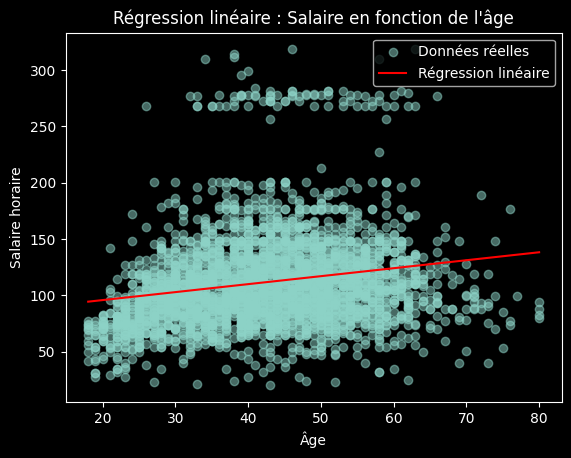

In [20]:
X = data["age"].values
Y = data["wage"].values

# Calculer la moyenne de X et Y 
X_mean = np.mean(X)
Y_mean = np.mean(Y)

# Calculer le coefficient beta_1 (pente)
Sxy = np.sum((X - X_mean) * (Y - Y_mean))
Sxx = np.sum((X - X_mean) ** 2)
beta_1 = Sxy / Sxx

# Calculer le coefficient beta_0 (intercept)
beta_0 = Y_mean - beta_1 * X_mean

# Afficher les coefficients
print(f"beta_0 (intercept): {beta_0}")
print(f"beta_1 (pente): {beta_1}")

# Calculer avec les librairies statsmodels et sklearn
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# Ajout de la constante pour inclure l'intercept dans le modèle
X_with_const = sm.add_constant(X)
# Appliquer le modèle de statsmodels
model = sm.OLS(Y, X_with_const).fit()
# Afficher le résumé des résultats
print(model.summary())

# Création du modèle de régression linéaire avec sklearn
model_sklearn = LinearRegression()
# Transformation de X en une matrice colonne
X_reshaped = X.reshape(-1, 1)
# Entraîner le modèle
model_sklearn.fit(X_reshaped, Y)
# Afficher les coefficients
print(f"Coefficient beta_1 avec scikit-learn : {model_sklearn.coef_[0]:.4f}")
print(f"Intercept beta_0 avec scikit-learn : {model_sklearn.intercept_:.4f}")

# Visualisation de la relation entre l'âge et le salaire

# Tracer le nuage de points des données
plt.scatter(X, Y, alpha=0.5, label='Données réelles')
# Générer une droite de régression
age_range = np.linspace(min(X), max(X), 100) # Intervalle d'âge
predicted_wage = beta_0 + beta_1 * age_range
# Tracer la droite de régression
plt.plot(age_range, predicted_wage, color='red', label='Régression linéaire')
# Ajouter des labels et un titre
plt.xlabel('Âge')
plt.ylabel('Salaire horaire')
plt.title('Régression linéaire : Salaire en fonction de l\'âge')
plt.legend()
plt.show()

#### 3.6, 3.7 *Calcul du coefficient de détermination et analyse des résidus*

Coefficient de détermination R^2 : 0.0383


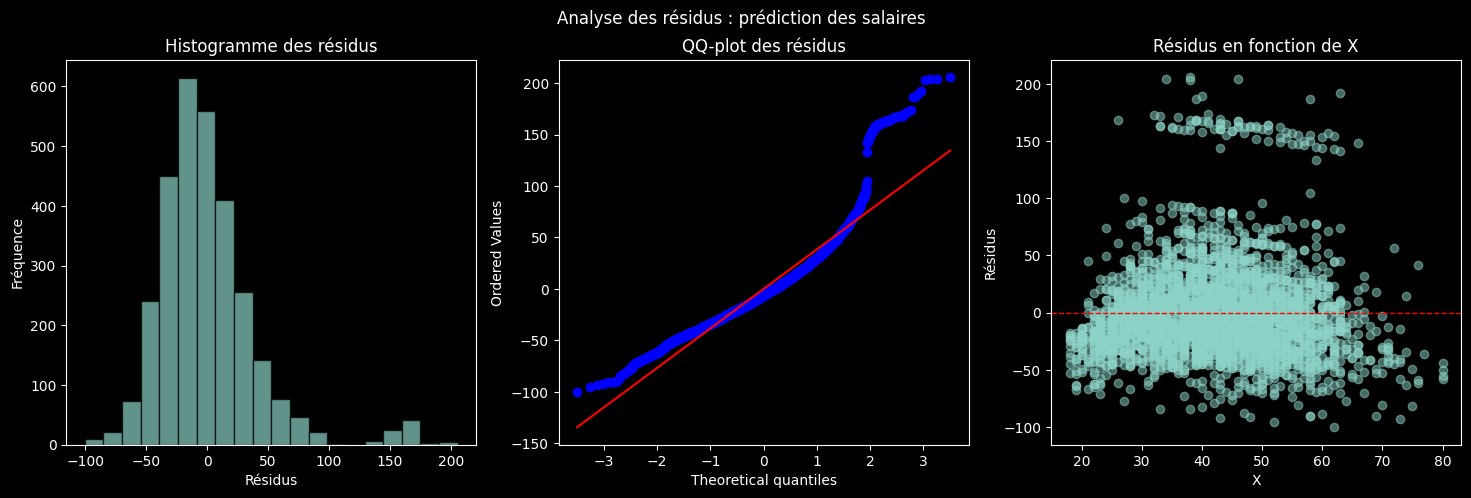

In [21]:
# Calcul de la somme des carrés totale (SC_totale)
Y_mean = np.mean(Y)
SC_totale = np.sum((Y - Y_mean) ** 2)
# Calcul de la somme des carrés expliquée par la régression (SC_reg)
Y_hat = beta_0 + beta_1 * X
SC_reg = np.sum((Y_hat - Y_mean) ** 2)
# Calcul de R²
R2 = SC_reg / SC_totale
# Afficher R²
print(f"Coefficient de détermination R^2 : {R2:.4f}")

import scipy.stats as stats

# Fonction pour tracer les graphiques de résidus
def plot_residuals(X, Y, Y_pred, title):
    residuals = Y - Y_pred

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Histogramme des résidus
    axes[0].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    axes[0].set_title('Histogramme des résidus')
    axes[0].set_xlabel('Résidus')
    axes[0].set_ylabel('Fréquence')

    # QQ-plot des résidus
    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].set_title('QQ-plot des résidus')

    # Graphique des résidus
    axes[2].scatter(X, residuals, alpha=0.5)
    axes[2].axhline(0, color='red', linestyle='dashed', linewidth=1)
    axes[2].set_title('Résidus en fonction de X')
    axes[2].set_xlabel('X')
    axes[2].set_ylabel('Résidus')

    plt.suptitle(title)
    plt.show()

plot_residuals(X, Y, Y_hat, 'Analyse des résidus : prédiction des salaires')



### **Régression linéaire multiple**

In [22]:
# Sélectionner les variables explicatives
X_multi_frame = data.drop(columns=["wage", "logwage"])  # Exclure la variable cible 

# Convertir les variables catégoriques en variables numériques (one-hot encoding)
X_multi = pd.get_dummies(X_multi_frame, drop_first=True)
# Conversion en float (manipulation de matrices)
X_multi = X_multi.astype(float)

# Extraire la variable cible
Y_multi = data["wage"].values

# Ajouter une colonne de 1 pour l'intercept
X_multi_with_1 = np.hstack((np.ones((X_multi.shape[0], 1)), X_multi))

# Calcul des coefficients avec la formule des moindres carrés ordinaires
beta = np.linalg.inv(X_multi_with_1.T @ X_multi_with_1) @ X_multi_with_1.T @ Y_multi

# Afficher les coefficients
print("Coefficients estimés du modèle :")
print(beta)

Coefficients estimés du modèle :
[-2.42332907e+03  1.24121732e+00  2.70688400e-01  1.71767352e+01
  2.05172604e+00  3.96658891e+00  1.15301439e+01 -5.09626383e+00
 -2.81409175e+00 -6.05883135e+00  7.75920388e+00  1.83404982e+01
  3.12398024e+01  5.39485141e+01  3.57066882e+00  6.51512362e+00
 -1.75125344e+01]


#### 4.3 *Comparaisons des modèles statsmodels et scikit-learn*

In [23]:
# Ajouter une constante pour inclure l'intercept dans le modèle
X_multi_with_const = sm.add_constant(X_multi)
# Ajustement du modèle de régression linéaire multiple avec statsmodels
model_multi = sm.OLS(Y_multi, X_multi_with_const).fit()
# Afficher le résumé des résultats
print(model_multi.summary())

# Création du modèle de régression linéaire multiple avec sklearn
model_multi_sklearn = LinearRegression()
# Entraîner le modèle
model_multi_sklearn.fit(X_multi, Y_multi)
# Afficher les coefficients
print("Coefficients avec scikit-learn :")
print(f"Intercept : {model_multi_sklearn.intercept_:.4f}")
print(f"Coefficients : {model_multi_sklearn.coef_}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.340
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     95.89
Date:                Mon, 06 Oct 2025   Prob (F-statistic):          2.84e-254
Time:                        18:53:56   Log-Likelihood:                -14827.
No. Observations:                3000   AIC:                         2.969e+04
Df Residuals:                    2983   BIC:                         2.979e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

#### 4.4 *Analyse de la variance (ANOVA)*

In [24]:
from scipy.stats import f
from tabulate import tabulate

# Calculer le Y prédit
Y_pred = X_multi_with_1 @ beta

def compute_anova(Y, Y_pred, n, p):
    Y_mean = np.mean(Y)

    # Somme des carrés totale
    SC_totale = np.sum((Y - Y_mean) ** 2)
    # Somme des carrés expliquée par la régression
    SC_reg = np.sum((Y_pred - Y_mean) ** 2)
    # Somme des carrés des résidus
    SC_res = np.sum((Y - Y_pred) ** 2)

    # Degrés de liberté
    dl_reg = p  # Degrés de liberté pour la régression
    dl_res = n - p - 1 # Degrés de liberté pour les résidus

    # Moyennes des carrés
    MC_reg = SC_reg / dl_reg
    MC_res = SC_res / dl_res

    # Statistique F
    F_stat = MC_reg / MC_res
    # Valeur p
    p_value = 1 - f.cdf(F_stat, dl_reg, dl_res)

    # Création du tableau ANOVA
    anova_table = pd.DataFrame({
        'Source': ['Régression', 'Résiduel', 'Total'],
        'Somme des carrés (SC)': [SC_reg, SC_res, SC_totale],
        'Degrés de liberté (dl)': [dl_reg, dl_res, dl_reg + dl_res],
        'Moyenne des carrés (MC)': [MC_reg, MC_res, ''],
        'F_stat': [F_stat, '', ''],
        'p-value': [p_value, '', '']
    })


    return anova_table

# Combiner intercept + coefficients
beta_full = np.concatenate(([model_multi_sklearn.intercept_], model_multi_sklearn.coef_))

# Obtention des Y_pred selon la librairie utilisée
Y_pred_mco = X_multi_with_1 @ model_multi.params
Y_pred_sklearn = X_multi_with_1 @ beta_full

# Appels de la fonction ANOVA sur les modèles
anova_mco = compute_anova(Y_multi, Y_pred_mco, n=len(Y_multi), p=X_multi.shape[1])
anova_sklearn = compute_anova(Y_multi, Y_pred_sklearn, X_multi.shape[0], X_multi.shape[1])

# Affichage des tableaux ANOVA
print("\nTableau ANOVA avec la formule des Moindres Carrés Ordinaires (MCO)")
print(tabulate(anova_mco, headers='keys', tablefmt='grid', showindex=False, floatfmt=".4f"))
print("\nTableau ANOVA avec 'LinearRegression' de scikit-learn")
print(tabulate(anova_sklearn, headers='keys', tablefmt='grid', showindex=False, floatfmt=".4f"))


Tableau ANOVA avec la formule des Moindres Carrés Ordinaires (MCO)
+------------+-------------------------+--------------------------+---------------------------+-------------------+------------------------+
| Source     |   Somme des carrés (SC) |   Degrés de liberté (dl) | Moyenne des carrés (MC)   | F_stat            | p-value                |
+============+=========================+==========================+===========================+===================+========================+
| Régression |            1773587.6705 |                       16 | 110849.2294051593         | 95.88616313560226 | 1.1102230246251565e-16 |
+------------+-------------------------+--------------------------+---------------------------+-------------------+------------------------+
| Résiduel   |            3448498.0992 |                     2983 | 1156.0503182132366        |                   |                        |
+------------+-------------------------+--------------------------+-------------------

#### 4.5 *Analyse des coefficients individuels avec statsmodels*

In [25]:
import re
from sklearn.metrics import r2_score
import statsmodels.formula.api as smf

# Création d'un DataFrame avec les variables explicatives et la variable cible
data_df = pd.concat([pd.DataFrame(X_multi_frame, columns=X_multi_frame.columns), pd.Series(Y, name='wage')], axis=1)
# Remplacement des caractères spéciaux dans les noms de colonnes
def clean_column_name(col_name):
    # Remplace tout caractère non alphanumérique par un underscore
    return re.sub(r"[^\w]", "_", col_name)

data_df.columns = [clean_column_name(col) for col in data_df.columns]

# Construction de la formule en évitant les erreurs liées aux caractères spéciaux
formula = 'wage ~ ' + ' + '.join(data_df.columns.drop('wage'))

# Ajustement du modèle avec statsmodels en utilisant la formule
model = smf.ols(formula=formula, data=data_df, ).fit()

# Calcul du tableau ANOVA avec statsmodels
anova_sm = sm.stats.anova_lm(model, typ=1)

print("\nTableau ANOVA avec 'OLS' de statsmodels")
print(tabulate(anova_sm, headers='keys', tablefmt='grid', floatfmt=".4f"))

# Calcul et affichage des coefficients individuels avec leurs p-values
print("\nCoefficients individuels avec leurs p-values :")
print(model.summary())

r2_mco = r2_score(Y_multi, Y_pred_mco)
print(f"\n R^2 obtenu par chaque méthode :")
print("Statsmodels R2 :", model.rsquared)
print("Sklearn R2 :", r2_score(Y_multi, model_multi_sklearn.predict(X_multi)))
print("Moindres carrés ordinaires R2 :", r2_mco)


Tableau ANOVA avec 'OLS' de statsmodels
+------------+-----------+--------------+-------------+----------+----------+
|            |        df |       sum_sq |     mean_sq |        F |   PR(>F) |
+============+===========+==============+=============+==========+==========+
| maritl     |    4.0000 |  363144.3644 |  90786.0911 |  78.5313 |   0.0000 |
+------------+-----------+--------------+-------------+----------+----------+
| race       |    3.0000 |   36165.2250 |  12055.0750 |  10.4278 |   0.0000 |
+------------+-----------+--------------+-------------+----------+----------+
| education  |    4.0000 | 1092930.2642 | 273232.5660 | 236.3501 |   0.0000 |
+------------+-----------+--------------+-------------+----------+----------+
| region     |    0.0000 |       0.0000 |    nan      | nan      | nan      |
+------------+-----------+--------------+-------------+----------+----------+
| jobclass   |    1.0000 |   20354.4666 |  20354.4666 |  17.6069 |   0.0000 |
+------------+---------

#### 4.6 *Analyse des résidus*

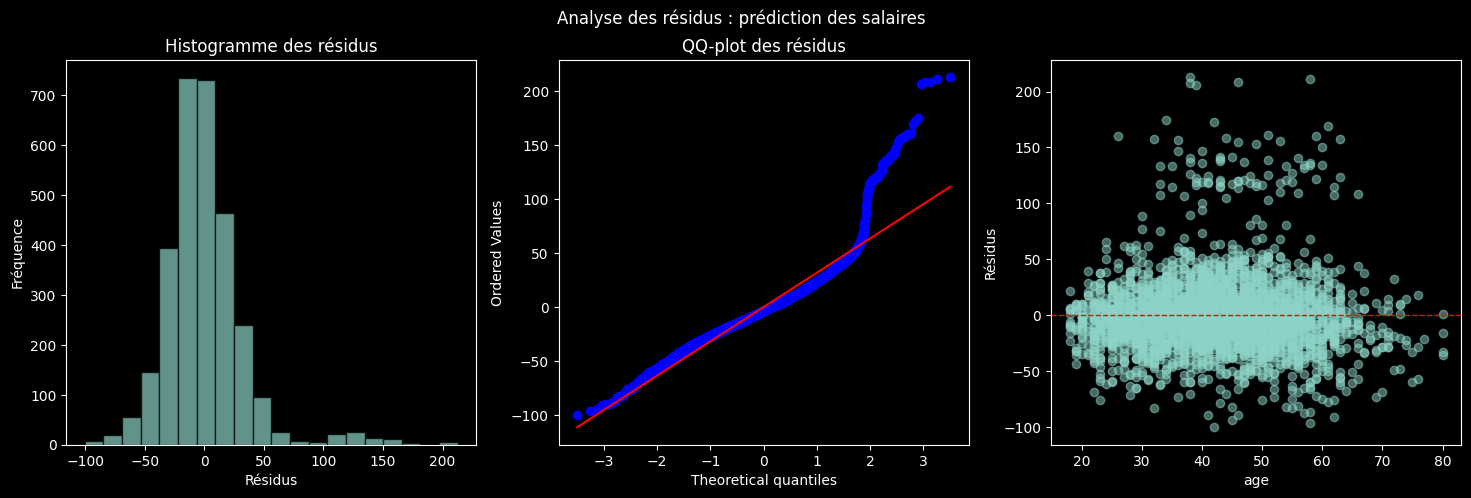

In [ ]:
# Fonction pour tracer les graphiques de résidus
def plot_residuals(X, Y, Y_pred, feature_name, title):
    residuals = Y - Y_pred

    fig, axes = plt.subplots(1, 3, figsize=(18,5))

    # Histogramme des résidus
    axes[0].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    axes[0].set_title("Histogramme des résidus")
    axes[0].set_xlabel("Résidus")
    axes[0].set_ylabel("Fréquence")

    # QQ-plot des résidus
    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].set_title("QQ-plot des résidus")

    # Graphique des résidus en fonction de âge
    if feature_name in X.columns:
        feature_values = X[feature_name]
    else:
        raise ValueError(f"La variable '{feature_name}' n'existe pas dans X.")
    
    axes[2].scatter(feature_values, residuals, alpha=0.5)
    axes[2].axhline(0, color='red', linestyle='dashed', linewidth=1)
    axes[2].set_xlabel(feature_name)
    axes[2].set_ylabel("Résidus")

    plt.suptitle(title)
    plt.show()

# Appel de la fonction avec age comme variable explicative
plot_residuals(X_multi, Y_multi, (X_multi_with_1 @ beta), "age", "Analyse des résidus : prédiction des salaires" )